## 05 - Rede Neural MLPClassifier

**Tech Challenge — Fase 1 | Machine Learning Engineering — FIAP**

**Projeto:** Customer Churn Prediction

**Grupo:** 56

---

### ETAPA 1 - Introdução e Objetivos

Após a construção da Regressão Logística como modelo baseline e do Random Forest como abordagem baseada em ensemble de árvores, esta etapa tem como objetivo desenvolver e avaliar uma Rede Neural Artificial utilizando o `MLPClassifier`.

O Multi-Layer Perceptron (MLP) é uma rede neural feedforward composta por camadas de neurônios capazes de aprender relações não lineares entre as variáveis de entrada e a variável alvo.

Para garantir uma comparação consistente entre os modelos, serão mantidos o mesmo conjunto de dados, a mesma divisão entre treino e teste e o mesmo protocolo de avaliação utilizado nos experimentos anteriores.

Como redes neurais são sensíveis à escala das variáveis, as características numéricas serão padronizadas antes do treinamento.

O desempenho será avaliado por meio das métricas Accuracy, Precision, Recall, F1-Score, ROC-AUC e Average Precision, além da matriz de confusão e das curvas ROC e Precision-Recall.

Também será aplicada validação cruzada estratificada para avaliar a estabilidade do modelo.

### Objetivos

- construir um pipeline de pré-processamento adequado ao MLPClassifier;
- padronizar as variáveis numéricas;
- treinar uma Rede Neural Artificial para previsão de churn;
- gerar classes e probabilidades previstas;
- avaliar o desempenho utilizando as métricas definidas no projeto;
- analisar os erros por meio da matriz de confusão;
- avaliar as curvas ROC e Precision-Recall;
- aplicar validação cruzada estratificada;
- analisar o comportamento do treinamento da rede neural;
- registrar os resultados para posterior comparação com a Regressão Logística e o Random Forest.

---

In [30]:
# ============================================================
# ETAPA 2 - IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)

from sklearn.neural_network import MLPClassifier

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)


# ------------------------------------------------------------
# Configurações gerais
# ------------------------------------------------------------

RANDOM_STATE = 42

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_colwidth",
    None
)


print("Bibliotecas importadas com sucesso.")

print(
    f"Random State definido: "
    f"{RANDOM_STATE}"
)

Bibliotecas importadas com sucesso.
Random State definido: 42


In [16]:
# ============================================================
# ETAPA 3 - CARREGAMENTO DA BASE DE DADOS
# ============================================================

DATASET_NAME = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

current_path = Path.cwd().resolve()

project_root = None


for path in [current_path, *current_path.parents]:

    candidate = (
        path
        / "data"
        / "raw"
        / DATASET_NAME
    )

    if candidate.exists():
        project_root = path
        break


if project_root is None:
    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto contendo "
        f"data/raw/{DATASET_NAME}"
    )


DATA_PATH = (
    project_root
    / "data"
    / "raw"
    / DATASET_NAME
)


df = pd.read_csv(
    DATA_PATH
)


print("Base carregada com sucesso.")

print(
    f"Quantidade de registros: "
    f"{df.shape[0]:,}"
    .replace(",", ".")
)

print(
    f"Quantidade de variáveis: "
    f"{df.shape[1]}"
)

print(
    f"Arquivo utilizado: "
    f"{DATA_PATH.name}"
)


display(
    df.head()
)

Base carregada com sucesso.
Quantidade de registros: 7.043
Quantidade de variáveis: 21
Arquivo utilizado: WA_Fn-UseC_-Telco-Customer-Churn.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Conclusão da ETAPA 3

A base Telco Customer Churn foi carregada com sucesso, contendo 7.043 registros e 21 variáveis.

A utilização da mesma fonte de dados empregada nos experimentos anteriores garante consistência metodológica e permite que o desempenho do MLPClassifier seja posteriormente comparado com a Regressão Logística e o Random Forest.

---

### ETAPA 4 - Preparação das Variáveis

Nesta etapa são realizadas as transformações necessárias para preparar as variáveis utilizadas no treinamento do MLPClassifier.

A variável `TotalCharges` será convertida para formato numérico e a variável alvo `Churn` será padronizada para representação binária, em que `0` representa clientes que permaneceram e `1` representa clientes que realizaram churn.

O identificador `customerID` será removido das variáveis explicativas, pois não representa uma característica preditiva do comportamento do cliente.

A mesma preparação utilizada nos modelos anteriores será mantida para garantir consistência na comparação dos experimentos.

In [17]:
# ============================================================
# ETAPA 4 - PREPARAÇÃO DAS VARIÁVEIS
# ============================================================

df = df.copy()

# ------------------------------------------------------------
# Conversão da variável TotalCharges
# ------------------------------------------------------------

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# ------------------------------------------------------------
# Preparação da variável alvo
# ------------------------------------------------------------

if not pd.api.types.is_numeric_dtype(
    df["Churn"]
):

    df["Churn"] = (
        df["Churn"]
        .astype(str)
        .str.strip()
        .map({
            "No": 0,
            "Yes": 1
        })
    )


# ------------------------------------------------------------
# Validação da variável alvo
# ------------------------------------------------------------

if df["Churn"].isna().any():

    raise ValueError(
        "Foram encontrados valores inválidos ou ausentes "
        "na variável alvo Churn."
    )


df["Churn"] = (
    df["Churn"]
    .astype(int)
)


if not set(
    df["Churn"].unique()
).issubset({0, 1}):

    raise ValueError(
        "A variável Churn deve conter somente "
        "os valores 0 e 1."
    )

# ------------------------------------------------------------
# Separação entre X e y
# ------------------------------------------------------------

X = df.drop(
    columns=[
        "customerID",
        "Churn"
    ]
)

y = df["Churn"]

# ------------------------------------------------------------
# Resumo
# ------------------------------------------------------------

print(
    "Variáveis preparadas com sucesso."
)

print(
    f"Variáveis explicativas: "
    f"{X.shape[1]}"
)

print(
    f"Observações: "
    f"{X.shape[0]:,}"
    .replace(",", ".")
)

print(
    f"Classe positiva (Churn): "
    f"{y.sum():,}"
    .replace(",", ".")
)

print(
    f"Taxa de Churn: "
    f"{y.mean():.2%}"
)

Variáveis preparadas com sucesso.
Variáveis explicativas: 19
Observações: 7.043
Classe positiva (Churn): 1.869
Taxa de Churn: 26.54%


#### Conclusão da ETAPA 4

As variáveis foram preparadas com sucesso para o treinamento do MLPClassifier.

Após a remoção do identificador `customerID`, o conjunto passou a conter 19 variáveis explicativas e 7.043 observações.

A classe positiva possui 1.869 registros, correspondentes a aproximadamente 26,54% da base, mantendo o cenário de desbalanceamento identificado nos experimentos anteriores.

Essa característica reforça a necessidade de avaliar o modelo utilizando métricas além da Accuracy, especialmente Recall, F1-Score e Average Precision.

---

### ETAPA 5 - Divisão entre Treino e Teste

Nesta etapa, os dados serão divididos em dois conjuntos:

- conjunto de treinamento, utilizado para ajustar o modelo;
- conjunto de teste, utilizado posteriormente para avaliar sua capacidade de generalização.

Será utilizada uma divisão de 80% para treinamento e 20% para teste.

A estratificação pela variável `Churn` será aplicada para preservar a proporção da classe positiva nos dois conjuntos.

O mesmo `random_state=42` utilizado nos modelos anteriores será mantido para garantir comparabilidade entre os experimentos.

In [18]:
# ============================================================
# ETAPA 5 - DIVISÃO TREINO / TESTE
# ============================================================
# Separação dos dados em conjuntos de treinamento e teste.
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

# ------------------------------------------------------------
# Informações da divisão
# ------------------------------------------------------------

print("Divisão realizada com sucesso.")

print(
    f"Treino: "
    f"{X_train.shape[0]:,}"
    .replace(",", ".")
    + " observações"
)

print(
    f"Teste: "
    f"{X_test.shape[0]:,}"
    .replace(",", ".")
    + " observações"
)

# ------------------------------------------------------------
# Verificação da proporção de churn
# ------------------------------------------------------------

train_churn_rate = y_train.mean()
test_churn_rate = y_test.mean()


print(
    f"Taxa de Churn no treino: "
    f"{train_churn_rate:.2%}"
)

print(
    f"Taxa de Churn no teste: "
    f"{test_churn_rate:.2%}"
)

Divisão realizada com sucesso.
Treino: 5.634 observações
Teste: 1.409 observações
Taxa de Churn no treino: 26.54%
Taxa de Churn no teste: 26.54%


#### Conclusão da ETAPA 5

A divisão dos dados foi realizada com sucesso, utilizando 80% das observações para treinamento e 20% para teste.

O conjunto de treinamento possui 5.634 observações, enquanto o conjunto de teste possui 1.409 observações.

A estratificação pela variável `Churn` preservou a proporção da classe positiva nos dois conjuntos, mantendo uma taxa de churn de aproximadamente 26,54%.

Essa abordagem garante uma divisão consistente dos dados e permite avaliar o MLPClassifier em observações que não foram utilizadas durante seu treinamento.

---

### ETAPA 6 - Pré-processamento das Variáveis

Nesta etapa será construído o pré-processador utilizado pelo MLPClassifier.

As variáveis numéricas serão submetidas à imputação de valores ausentes pela mediana e posteriormente padronizadas utilizando `StandardScaler`.

A padronização é especialmente importante para redes neurais, pois evita que variáveis com escalas numéricas maiores exerçam influência desproporcional durante o processo de otimização.

As variáveis categóricas serão submetidas à imputação pela categoria mais frequente e posteriormente transformadas utilizando One-Hot Encoding.

O pré-processamento será integrado posteriormente ao pipeline do modelo, garantindo que as transformações sejam aprendidas exclusivamente a partir dos dados de treinamento.

In [19]:
# ============================================================
# ETAPA 6 - PRÉ-PROCESSAMENTO
# ============================================================
# Construção do pré-processador específico para o MLP.
# ============================================================

# ------------------------------------------------------------
# Identificação das variáveis
# ------------------------------------------------------------

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()


# ------------------------------------------------------------
# Pipeline das variáveis numéricas
# ------------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# ------------------------------------------------------------
# Pipeline das variáveis categóricas
# ------------------------------------------------------------

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ------------------------------------------------------------
# ColumnTransformer
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

# ------------------------------------------------------------
# Verificação
# ------------------------------------------------------------

print(
    "Pré-processador criado com sucesso."
)

print(
    f"Variáveis numéricas: "
    f"{len(numeric_features)}"
)

print(
    f"Variáveis categóricas: "
    f"{len(categorical_features)}"
)

print(
    "\nVariáveis numéricas:"
)

print(
    numeric_features
)

print(
    "\nVariáveis categóricas:"
)

print(
    categorical_features
)

Pré-processador criado com sucesso.
Variáveis numéricas: 4
Variáveis categóricas: 15

Variáveis numéricas:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Variáveis categóricas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


#### Conclusão da ETAPA 6

O pré-processador foi configurado com sucesso, identificando 4 variáveis numéricas e 15 variáveis categóricas.

As variáveis numéricas serão imputadas pela mediana e padronizadas pelo `StandardScaler`, enquanto as variáveis categóricas serão imputadas pela categoria mais frequente e transformadas por One-Hot Encoding.

A utilização do `StandardScaler` é particularmente relevante para o MLPClassifier, pois contribui para uma otimização mais estável da rede neural ao colocar as variáveis numéricas em uma escala comparável.

O pré-processamento será incorporado ao pipeline do modelo, evitando vazamento de informações entre os conjuntos de treinamento e teste.

---

### ETAPA 7 - Construção e Treinamento do MLPClassifier

Nesta etapa será construído o pipeline completo do MLPClassifier, integrando o pré-processamento das variáveis ao modelo de Rede Neural.

Será utilizada uma arquitetura inicial com uma camada oculta contendo 64 neurônios e função de ativação ReLU.

O treinamento utilizará o algoritmo Adam para otimização dos pesos, com regularização L2 por meio do parâmetro `alpha`.

Será utilizado `early_stopping=True`, permitindo que o treinamento seja interrompido quando não houver melhora suficiente no desempenho sobre uma parcela de validação interna.

O `random_state=42` será mantido para garantir reprodutibilidade dos resultados.

In [20]:
# ============================================================
# ETAPA 7.1 - CONSTRUÇÃO DO PIPELINE MLP
# ============================================================

mlp_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            MLPClassifier(
                hidden_layer_sizes=(64,),
                activation="relu",
                solver="adam",
                alpha=0.0001,
                batch_size=32,
                learning_rate_init=0.001,
                max_iter=300,
                early_stopping=True,
                validation_fraction=0.10,
                n_iter_no_change=20,
                random_state=RANDOM_STATE
            )
        )
    ]
)


print(
    "Pipeline MLP criado com sucesso."
)

print(
    "\nConfiguração inicial:"
)

print(
    "Camada oculta: 64 neurônios"
)

print(
    "Função de ativação: ReLU"
)

print(
    "Otimizador: Adam"
)

print(
    "Alpha (regularização L2): 0.0001"
)

print(
    "Batch Size: 32"
)

print(
    "Learning Rate inicial: 0.001"
)

print(
    "Máximo de iterações: 300"
)

print(
    "Early Stopping: True"
)

print(
    "Random State: 42"
)

Pipeline MLP criado com sucesso.

Configuração inicial:
Camada oculta: 64 neurônios
Função de ativação: ReLU
Otimizador: Adam
Alpha (regularização L2): 0.0001
Batch Size: 32
Learning Rate inicial: 0.001
Máximo de iterações: 300
Early Stopping: True
Random State: 42


In [21]:
# ============================================================
# ETAPA 7.2 - TREINAMENTO DO MLP
# ============================================================

start_time = perf_counter()


mlp_pipeline.fit(
    X_train,
    y_train
)


training_time = (
    perf_counter() - start_time
)


mlp_model = mlp_pipeline.named_steps[
    "classifier"
]


print(
    "MLP treinado com sucesso."
)

print(
    f"Tempo de treinamento: "
    f"{training_time:.2f} segundos"
)

print(
    f"Observações utilizadas no treinamento: "
    f"{X_train.shape[0]:,}"
    .replace(",", ".")
)

print(
    f"Iterações realizadas: "
    f"{mlp_model.n_iter_}"
)

print(
    f"Loss final: "
    f"{mlp_model.loss_:.6f}"
)

MLP treinado com sucesso.
Tempo de treinamento: 3.86 segundos
Observações utilizadas no treinamento: 5.634
Iterações realizadas: 60
Loss final: 0.356358


In [8]:
# ============================================================
# ETAPA 7.3 - VERIFICAÇÃO DO MODELO
# ============================================================

print(
    "Verificação do modelo treinado:"
)

print(
    f"Número de camadas ocultas: "
    f"{mlp_model.n_layers_ - 2}"
)

print(
    f"Arquitetura da camada oculta: "
    f"{mlp_model.hidden_layer_sizes}"
)

print(
    f"Número total de camadas: "
    f"{mlp_model.n_layers_}"
)

print(
    f"Número de iterações realizadas: "
    f"{mlp_model.n_iter_}"
)

print(
    f"Loss final: "
    f"{mlp_model.loss_:.6f}"
)

print(
    f"Classes reconhecidas pelo modelo: "
    f"{mlp_model.classes_}"
)

print(
    f"Número de classes: "
    f"{len(mlp_model.classes_)}"
)

Verificação do modelo treinado:
Número de camadas ocultas: 1
Arquitetura da camada oculta: (64,)
Número total de camadas: 3
Número de iterações realizadas: 60
Loss final: 0.356358
Classes reconhecidas pelo modelo: [0 1]
Número de classes: 2


#### Conclusão da ETAPA 7

O pipeline do MLPClassifier foi construído e treinado com sucesso, integrando o pré-processamento das variáveis ao modelo de Rede Neural.

A arquitetura inicial utiliza uma camada oculta com 64 neurônios e função de ativação ReLU, utilizando o otimizador Adam e regularização L2.

A estratégia de `early_stopping` permite interromper o treinamento quando não são observadas melhorias suficientes no conjunto de validação interno, contribuindo para reduzir o risco de sobreajuste.

O modelo reconheceu corretamente as duas classes da variável alvo, estando preparado para a geração das previsões e probabilidades sobre o conjunto de teste.

---

### ETAPA 8 - Predições e Probabilidades

Nesta etapa serão geradas as previsões do MLPClassifier para o conjunto de teste.

Serão obtidas tanto as classes previstas quanto as probabilidades associadas à ocorrência de churn.

A probabilidade da classe positiva será utilizada posteriormente para classificar o nível de risco dos clientes e gerar uma interpretação individual das previsões.

In [23]:
# ============================================================
# ETAPA 8.1 - GERAÇÃO DAS CLASSES PREVISTAS
# ============================================================

y_pred = mlp_pipeline.predict(
    X_test
)


print(
    "Classes previstas geradas com sucesso."
)

print(
    f"Quantidade de previsões: "
    f"{len(y_pred):,}"
    .replace(",", ".")
)

print(
    f"Previsões de Não Churn (0): "
    f"{(y_pred == 0).sum():,}"
    .replace(",", ".")
)

print(
    f"Previsões de Churn (1): "
    f"{(y_pred == 1).sum():,}"
    .replace(",", ".")
)

print(
    "\nPrimeiras 10 classes previstas:"
)

print(
    y_pred[:10]
)

Classes previstas geradas com sucesso.
Quantidade de previsões: 1.409
Previsões de Não Churn (0): 1.142
Previsões de Churn (1): 267

Primeiras 10 classes previstas:
[0 1 0 0 0 1 1 0 0 0]


In [24]:
# ============================================================
# ETAPA 8.2 - PROBABILIDADES, NÍVEL DE RISCO E ANÁLISE
# ============================================================
# Geração das probabilidades de churn, classificação do
# nível de risco e interpretação individual de cada cliente.
# ============================================================

# Probabilidade de churn para a classe positiva (1)
y_proba = mlp_pipeline.predict_proba(
    X_test
)[:, 1]

# ------------------------------------------------------------
# Classificação do nível de risco
# ------------------------------------------------------------

def classificar_risco(probabilidade):

    if probabilidade < 0.20:
        return "Muito baixo"

    elif probabilidade < 0.40:
        return "Baixo"

    elif probabilidade < 0.60:
        return "Moderado"

    elif probabilidade < 0.80:
        return "Alto"

    else:
        return "Muito alto"

# ------------------------------------------------------------
# Geração da interpretação individual
# ------------------------------------------------------------

def gerar_analise(probabilidade):

    percentual = probabilidade * 100

    if probabilidade < 0.20:

        return (
            f"O cliente apresenta apenas "
            f"{percentual:.2f}% de probabilidade de churn, "
            f"indicando risco muito baixo de cancelamento."
        )

    elif probabilidade < 0.40:

        return (
            f"O cliente apresenta "
            f"{percentual:.2f}% de probabilidade de churn, "
            f"indicando risco baixo e necessidade de "
            f"acompanhamento eventual."
        )

    elif probabilidade < 0.60:

        return (
            f"O cliente apresenta "
            f"{percentual:.2f}% de probabilidade de churn, "
            f"indicando risco moderado e necessidade de "
            f"acompanhamento."
        )

    elif probabilidade < 0.80:

        return (
            f"O cliente apresenta "
            f"{percentual:.2f}% de probabilidade de churn, "
            f"indicando risco alto e potencial prioridade "
            f"para ações de retenção."
        )

    else:

        return (
            f"O cliente apresenta "
            f"{percentual:.2f}% de probabilidade de churn, "
            f"indicando risco muito alto e elevada prioridade "
            f"para ações de retenção."
        )

# ------------------------------------------------------------
# Construção da tabela de probabilidades
# ------------------------------------------------------------

proba_df = pd.DataFrame({
    "Observação": range(1, len(y_pred) + 1),
    "Classe Prevista": y_pred,
    "Probabilidade de Churn": y_proba
})


# Classificação do risco
proba_df["Nível de Risco"] = (
    proba_df["Probabilidade de Churn"]
    .apply(classificar_risco)
)


# Interpretação individual
proba_df["Análise"] = (
    proba_df["Probabilidade de Churn"]
    .apply(gerar_analise)
)


# Arredondamento da probabilidade
proba_df["Probabilidade de Churn"] = (
    proba_df["Probabilidade de Churn"]
    .round(4)
)

# ------------------------------------------------------------
# Exibição da tabela formatada
# ------------------------------------------------------------

pd.set_option(
    "display.max_colwidth",
    None
)

display(
    proba_df.head(10).style

        # ----------------------------------------------------
        # Centralização dos dados
        # ----------------------------------------------------

        .set_properties(
            subset=[
                "Observação",
                "Classe Prevista",
                "Probabilidade de Churn",
                "Nível de Risco"
            ],
            **{
                "text-align": "center"
            }
        )

        # ----------------------------------------------------
        # Análise alinhada à esquerda
        # ----------------------------------------------------

        .set_properties(
            subset=["Análise"],
            **{
                "min-width": "650px",
                "white-space": "normal",
                "text-align": "left"
            }
        )

        # ----------------------------------------------------
        # Cabeçalho centralizado
        # ----------------------------------------------------

        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold"),
                    ("vertical-align", "middle")
                ]
            },

            # Largura das colunas
            {
                "selector": "th.col_heading.level0",
                "props": [
                    ("text-align", "center")
                ]
            }
        ])
)

,Observação,Classe Prevista,Probabilidade de Churn,Nível de Risco,Análise
0,1,0,0.036000,Muito baixo,"O cliente apresenta apenas 3.60% de probabilidade de churn, indicando risco muito baixo de cancelamento."
1,2,1,0.896300,Muito alto,"O cliente apresenta 89.63% de probabilidade de churn, indicando risco muito alto e elevada prioridade para ações de retenção."
2,3,0,0.045200,Muito baixo,"O cliente apresenta apenas 4.52% de probabilidade de churn, indicando risco muito baixo de cancelamento."
3,4,0,0.178100,Muito baixo,"O cliente apresenta apenas 17.81% de probabilidade de churn, indicando risco muito baixo de cancelamento."
4,5,0,0.019000,Muito baixo,"O cliente apresenta apenas 1.90% de probabilidade de churn, indicando risco muito baixo de cancelamento."
5,6,1,0.724600,Alto,"O cliente apresenta 72.46% de probabilidade de churn, indicando risco alto e potencial prioridade para ações de retenção."
6,7,1,0.515600,Moderado,"O cliente apresenta 51.56% de probabilidade de churn, indicando risco moderado e necessidade de acompanhamento."
7,8,0,0.070900,Muito baixo,"O cliente apresenta apenas 7.09% de probabilidade de churn, indicando risco muito baixo de cancelamento."
8,9,0,0.003500,Muito baixo,"O cliente apresenta apenas 0.35% de probabilidade de churn, indicando risco muito baixo de cancelamento."
9,10,0,0.332700,Baixo,"O cliente apresenta 33.27% de probabilidade de churn, indicando risco baixo e necessidade de acompanhamento eventual."


#### Conclusão da ETAPA 8

O MLPClassifier gerou com sucesso as classes previstas e as respectivas probabilidades de churn para as 1.409 observações do conjunto de teste.

As probabilidades permitem complementar a classificação binária com uma visão gradual do risco de cancelamento, possibilitando identificar clientes com diferentes níveis de prioridade para ações de retenção.

A análise individual das probabilidades também permite transformar a saída técnica do modelo em uma informação mais interpretável para o contexto de negócio.

---

### ETAPA 9 - Avaliação das Métricas do MLPClassifier

Nesta etapa será avaliado o desempenho do MLPClassifier sobre o conjunto de teste.

Serão utilizadas diferentes métricas de classificação para obter uma visão abrangente da capacidade preditiva do modelo:

- **Accuracy:** proporção total de previsões corretas;
- **Precision:** proporção de clientes corretamente identificados como churn entre aqueles classificados pelo modelo como churn;
- **Recall:** proporção de clientes que realmente realizaram churn e foram corretamente identificados pelo modelo;
- **F1-Score:** média harmônica entre Precision e Recall;
- **ROC-AUC:** capacidade do modelo de discriminar clientes com e sem churn considerando diferentes thresholds;
- **Average Precision:** desempenho do modelo na relação entre Precision e Recall, sendo especialmente relevante em cenários com classes desbalanceadas.

Como o problema apresenta desbalanceamento entre as classes, será dada atenção especial às métricas Recall, F1-Score, ROC-AUC e Average Precision.

In [25]:
# ============================================================
# ETAPA 9.1 - CÁLCULO DAS MÉTRICAS DE CLASSIFICAÇÃO
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_proba
)

average_precision = average_precision_score(
    y_test,
    y_proba
)


# ------------------------------------------------------------
# Exibição das métricas
# ------------------------------------------------------------

print("Desempenho do MLPClassifier no conjunto de teste:\n")

print(
    f"Accuracy:          {accuracy:.4f}"
)

print(
    f"Precision:         {precision:.4f}"
)

print(
    f"Recall:            {recall:.4f}"
)

print(
    f"F1-Score:          {f1:.4f}"
)

print(
    f"ROC-AUC:           {roc_auc:.4f}"
)

print(
    f"Average Precision: {average_precision:.4f}"
)

Desempenho do MLPClassifier no conjunto de teste:

Accuracy:          0.7850
Precision:         0.6330
Recall:            0.4519
F1-Score:          0.5273
ROC-AUC:           0.8341
Average Precision: 0.6231


In [26]:
# ============================================================
# ETAPA 9.2 - TABELA RESUMO DAS MÉTRICAS
# ============================================================

metricas_mlp = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Average Precision"
    ],
    "Valor": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        average_precision
    ]
})

# ------------------------------------------------------------
# Formatação da tabela
# ------------------------------------------------------------

metricas_mlp["Valor"] = metricas_mlp["Valor"].round(4)

metricas_mlp

,Métrica,Valor
0,Accuracy,0.7850
1,Precision,0.6330
2,Recall,0.4519
3,F1-Score,0.5273
4,ROC-AUC,0.8341
5,Average Precision,0.6231


#### 9.3 - Interpretação das Métricas

O MLPClassifier apresentou **Accuracy de 78,50%**, indicando que aproximadamente 78,5% das observações do conjunto de teste foram classificadas corretamente. Entretanto, devido ao desbalanceamento existente entre clientes que permanecem e clientes que realizam churn, a acurácia não deve ser analisada isoladamente.

A **Precision de 63,30%** indica que, entre os clientes classificados pelo modelo como possíveis casos de churn, aproximadamente 63,3% realmente pertencem à classe positiva.

O **Recall de 45,19%** mostra que o modelo identificou aproximadamente 45,2% dos clientes que efetivamente realizaram churn. Esse resultado merece atenção do ponto de vista de negócio, pois significa que uma parcela relevante dos clientes que cancelam o serviço ainda não é identificada pelo modelo utilizando o threshold atual.

O **F1-Score de 52,73%** representa o equilíbrio entre Precision e Recall e evidencia espaço para melhoria na identificação da classe positiva.

Por outro lado, o modelo apresentou **ROC-AUC de 0,8341**, demonstrando boa capacidade de discriminação entre clientes com e sem churn considerando diferentes thresholds de classificação.

A **Average Precision de 0,6231** complementa essa análise ao avaliar a relação entre Precision e Recall ao longo de diferentes thresholds, sendo especialmente relevante neste problema devido ao desbalanceamento entre as classes.

De forma geral, os resultados mostram que o MLPClassifier possui boa capacidade de separação entre as classes, porém o threshold de classificação influencia diretamente sua capacidade de identificar clientes em risco. Nas próximas análises serão avaliados os erros de classificação e o trade-off entre falsos positivos e falsos negativos.

---

### ETAPA 10 - Matriz de Confusão

A matriz de confusão permite analisar detalhadamente os acertos e erros do MLPClassifier, separando as previsões em verdadeiros negativos, falsos positivos, falsos negativos e verdadeiros positivos.

Em um problema de previsão de churn, essa análise é particularmente importante porque os diferentes tipos de erro possuem impactos distintos para o negócio.

- **Verdadeiro Negativo (TN):** cliente que não realizou churn e foi corretamente classificado como não churn;
- **Falso Positivo (FP):** cliente que não realizou churn, mas foi classificado como possível churn;
- **Falso Negativo (FN):** cliente que realizou churn, mas não foi identificado pelo modelo;
- **Verdadeiro Positivo (TP):** cliente que realizou churn e foi corretamente identificado pelo modelo.

Os falsos negativos merecem atenção especial, pois representam clientes em risco de cancelamento que poderiam não receber uma ação preventiva de retenção.

In [27]:
# ============================================================
# ETAPA 10.1 - MATRIZ DE CONFUSÃO
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

tn, fp, fn, tp = cm.ravel()

# ------------------------------------------------------------
# Resultados
# ------------------------------------------------------------

print("Matriz de Confusão - MLPClassifier\n")

print(f"Verdadeiros Negativos (TN): {tn}")
print(f"Falsos Positivos (FP):      {fp}")
print(f"Falsos Negativos (FN):      {fn}")
print(f"Verdadeiros Positivos (TP): {tp}")

Matriz de Confusão - MLPClassifier

Verdadeiros Negativos (TN): 937
Falsos Positivos (FP):      98
Falsos Negativos (FN):      205
Verdadeiros Positivos (TP): 169


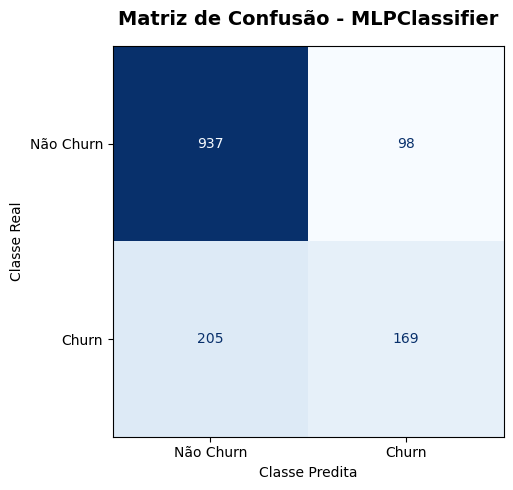

In [28]:
# ============================================================
# ETAPA 10.2 - VISUALIZAÇÃO DA MATRIZ DE CONFUSÃO
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Não Churn", "Churn"]
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

ax.set_title(
    "Matriz de Confusão - MLPClassifier",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Classe Predita")
ax.set_ylabel("Classe Real")

plt.tight_layout()
plt.show()

#### 10.3 - Análise da Matriz de Confusão

A matriz de confusão permite observar de forma mais detalhada o comportamento do MLPClassifier no conjunto de teste.

O modelo apresentou:

- **937 Verdadeiros Negativos (TN):** clientes que não realizaram churn e foram corretamente classificados como não churn;
- **98 Falsos Positivos (FP):** clientes que não realizaram churn, mas foram classificados como clientes em risco;
- **205 Falsos Negativos (FN):** clientes que realizaram churn, mas não foram identificados pelo modelo;
- **169 Verdadeiros Positivos (TP):** clientes que realizaram churn e foram corretamente identificados.

Entre os **374 clientes que realmente realizaram churn**, o modelo identificou corretamente **169 clientes**, equivalente a aproximadamente **45,2%**, enquanto **205 clientes**, aproximadamente **54,8%**, não foram identificados.

Esse resultado confirma o Recall de **45,19%** observado anteriormente e evidencia um ponto importante para o problema de negócio: utilizando o threshold atual, mais da metade dos clientes que efetivamente realizam churn não são sinalizados antecipadamente pelo modelo.

Por outro lado, entre os **1.035 clientes que não realizaram churn**, apenas 98 foram incorretamente classificados como clientes em risco, indicando que o modelo apresenta maior capacidade de reconhecer clientes que permanecem do que de identificar todos os casos de churn.

Em um cenário de retenção de clientes, os falsos negativos podem representar um custo relevante para a empresa, pois correspondem a clientes que cancelariam o serviço sem receber uma possível ação preventiva de retenção.

Dessa forma, existe um trade-off entre aumentar a capacidade de detectar clientes com risco de churn e evitar que clientes sem risco sejam classificados incorretamente. Esse comportamento será aprofundado posteriormente por meio da análise dos thresholds de classificação.

---

### ETAPA 11 - Curva ROC e ROC-AUC

A Curva ROC (Receiver Operating Characteristic) permite avaliar a capacidade do modelo de distinguir clientes que realizam churn daqueles que permanecem, considerando diferentes thresholds de classificação.

A curva relaciona:

- **True Positive Rate (TPR):** proporção de clientes com churn corretamente identificados;
- **False Positive Rate (FPR):** proporção de clientes sem churn classificados incorretamente como churn.

A métrica **ROC-AUC** resume o desempenho apresentado pela curva. Quanto mais próximo de 1,0 for o valor da AUC, maior é a capacidade do modelo de separar as duas classes.

In [31]:
# ============================================================
# ETAPA 11.1 - CÁLCULO DA CURVA ROC
# ============================================================

fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    y_proba
)

auc_roc = roc_auc_score(
    y_test,
    y_proba
)

# ------------------------------------------------------------
# Informações da Curva ROC
# ------------------------------------------------------------

print("Curva ROC - MLPClassifier\n")

print(f"ROC-AUC:                 {auc_roc:.4f}")
print(f"Quantidade de thresholds: {len(thresholds_roc)}")
print(f"Quantidade de pontos ROC: {len(fpr)}")

Curva ROC - MLPClassifier

ROC-AUC:                 0.8341
Quantidade de thresholds: 384
Quantidade de pontos ROC: 384


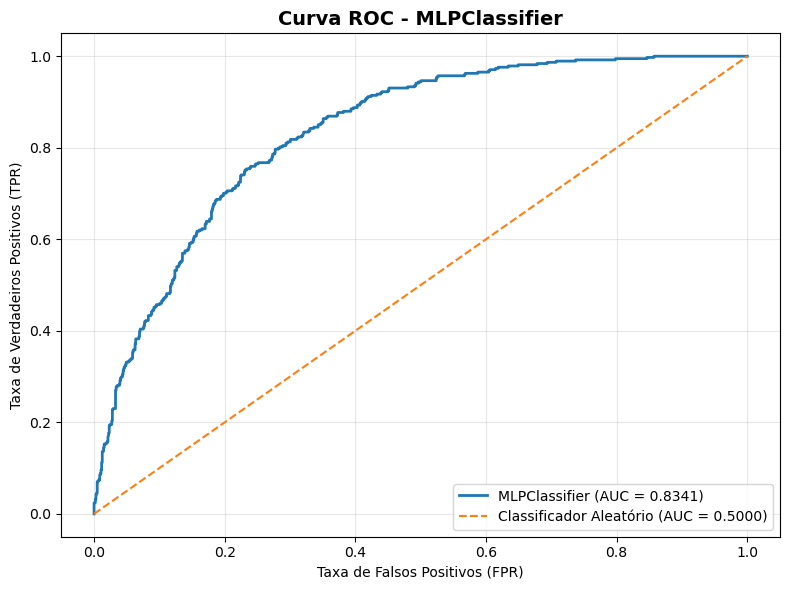

In [32]:
# ============================================================
# ETAPA 11.2 - VISUALIZAÇÃO DA CURVA ROC
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"MLPClassifier (AUC = {auc_roc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Classificador Aleatório (AUC = 0.5000)"
)

plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")

plt.title(
    "Curva ROC - MLPClassifier",
    fontsize=14,
    fontweight="bold"
)

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 11.3 - Interpretação da Curva ROC

A Curva ROC do MLPClassifier permanece significativamente acima da linha de referência de um classificador aleatório, demonstrando que o modelo possui capacidade consistente de discriminar clientes com e sem churn.

O modelo obteve **ROC-AUC de 0,8341**, resultado que indica boa capacidade de separação entre as duas classes ao considerar diferentes thresholds de classificação.

A análise da curva também evidencia que é possível aumentar a taxa de detecção dos clientes que realizam churn (True Positive Rate) por meio da redução do threshold de classificação. Entretanto, essa alteração tende a aumentar simultaneamente a taxa de falsos positivos (False Positive Rate).

Esse comportamento é particularmente relevante para o problema de negócio. Com o threshold atualmente utilizado, o modelo apresentou Recall de **45,19%**, identificando 169 dos 374 clientes que efetivamente realizaram churn. Apesar disso, o ROC-AUC mostra que o modelo possui capacidade discriminativa superior ao desempenho observado em um único ponto de corte.

Portanto, o desempenho do MLPClassifier não deve ser avaliado apenas pelo threshold padrão. A escolha do ponto de corte pode ser ajustada de acordo com os custos associados aos falsos positivos e falsos negativos e com a estratégia de retenção adotada pela empresa.

A análise conjunta da Curva ROC, ROC-AUC e matriz de confusão demonstra que o modelo apresenta boa capacidade de separação entre as classes, embora ainda exista oportunidade de melhorar a identificação de clientes com maior risco de churn.

---

### ETAPA 12 - Curva Precision-Recall

A Curva Precision-Recall permite analisar o equilíbrio entre a precisão das previsões positivas e a capacidade do modelo de identificar os clientes que efetivamente realizam churn.

Essa análise é especialmente relevante em problemas com classes desbalanceadas, pois concentra a avaliação no desempenho do modelo sobre a classe positiva.

A curva relaciona:

- **Precision:** proporção de clientes que realmente realizaram churn entre aqueles classificados como churn;
- **Recall:** proporção dos clientes que realizaram churn e foram corretamente identificados pelo modelo.

Além da curva, será utilizada a métrica **Average Precision (AP)** para resumir o desempenho do modelo considerando diferentes thresholds de classificação.

In [33]:
# ============================================================
# ETAPA 12.1 - CÁLCULO DA CURVA PRECISION-RECALL
# ============================================================

precision_curve, recall_curve, thresholds_pr = precision_recall_curve(
    y_test,
    y_proba
)

ap_score = average_precision_score(
    y_test,
    y_proba
)

# ------------------------------------------------------------
# Informações da Curva Precision-Recall
# ------------------------------------------------------------

print("Curva Precision-Recall - MLPClassifier\n")

print(f"Average Precision:         {ap_score:.4f}")
print(f"Quantidade de thresholds:  {len(thresholds_pr)}")
print(f"Quantidade de pontos PR:   {len(precision_curve)}")

Curva Precision-Recall - MLPClassifier

Average Precision:         0.6231
Quantidade de thresholds:  1407
Quantidade de pontos PR:   1408


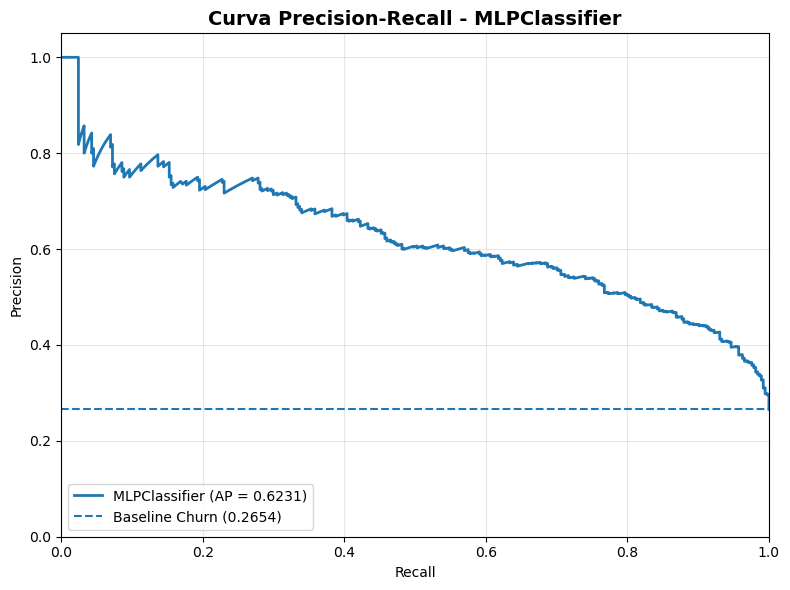

In [34]:
# ============================================================
# ETAPA 12.2 - VISUALIZAÇÃO DA CURVA PRECISION-RECALL
# ============================================================

# Proporção da classe positiva no conjunto de teste
baseline_churn = y_test.mean()

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f"MLPClassifier (AP = {ap_score:.4f})"
)

plt.axhline(
    y=baseline_churn,
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline Churn ({baseline_churn:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Curva Precision-Recall - MLPClassifier",
    fontsize=14,
    fontweight="bold"
)

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.legend(loc="lower left")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 12.3 - Interpretação da Curva Precision-Recall

A Curva Precision-Recall demonstra que o MLPClassifier apresenta desempenho significativamente superior à proporção de referência da classe positiva no conjunto de teste.

A proporção de clientes com churn no conjunto de teste é de aproximadamente **26,54%**, enquanto o modelo obteve **Average Precision de 0,6231**. Esse resultado indica que o modelo mantém uma relação entre Precision e Recall substancialmente superior à baseline ao considerar diferentes thresholds de classificação.

A curva também evidencia o trade-off existente entre as duas métricas. À medida que o Recall aumenta, permitindo identificar uma parcela maior dos clientes que efetivamente realizam churn, ocorre uma redução gradual da Precision. Isso significa que aumentar a capacidade de detecção de churn tende a gerar também mais falsos positivos.

Esse comportamento possui impacto direto na estratégia de negócio. Um threshold mais conservador reduz o número de clientes classificados incorretamente como churn, porém aumenta o risco de não identificar clientes que realmente cancelarão o serviço. Por outro lado, um threshold mais permissivo pode aumentar o Recall e permitir ações preventivas sobre uma parcela maior dos clientes em risco, ao custo de abordar também clientes que não realizariam churn.

Considerando o problema de retenção de clientes, a escolha do threshold deve levar em conta não apenas o desempenho estatístico do modelo, mas também os custos associados às ações de retenção e às perdas provocadas pelo churn.

Em conjunto com o ROC-AUC de **0,8341**, o Average Precision de **0,6231** reforça que o MLPClassifier possui capacidade relevante de discriminação e priorização dos clientes com maior risco de churn.

---

### ETAPA 13 - Análise de Threshold e Trade-off entre Falsos Positivos e Falsos Negativos

Até o momento, as classificações do MLPClassifier foram realizadas utilizando o threshold padrão de **0,50**.

Entretanto, em um problema de churn, falsos positivos e falsos negativos possuem consequências diferentes para o negócio.

Um **falso positivo** ocorre quando um cliente que permaneceria na empresa é classificado como possível churn. Nesse cenário, a empresa pode direcionar desnecessariamente uma ação de retenção para esse cliente.

Um **falso negativo** ocorre quando um cliente que efetivamente realizará churn não é identificado pelo modelo. Esse tipo de erro pode ser mais crítico, pois a empresa perde a oportunidade de realizar uma ação preventiva de retenção.

Dessa forma, serão avaliados diferentes thresholds de classificação para analisar como Precision, Recall, F1-Score, falsos positivos e falsos negativos se comportam conforme o ponto de corte é alterado.

In [35]:
# ============================================================
# ETAPA 13.1 - COMPARAÇÃO DE DIFERENTES THRESHOLDS
# ============================================================

thresholds_avaliados = [
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80
]

resultados_threshold = []

for threshold in thresholds_avaliados:

    y_pred_threshold = (
        y_proba >= threshold
    ).astype(int)

    tn_t, fp_t, fn_t, tp_t = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    resultados_threshold.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "FP": fp_t,
        "FN": fn_t,
        "TP": tp_t,
        "TN": tn_t
    })


df_thresholds = pd.DataFrame(
    resultados_threshold
)


# ------------------------------------------------------------
# Formatação para visualização
# ------------------------------------------------------------

df_thresholds_formatado = (
    df_thresholds
    .style
    .format({
        "Threshold": "{:.2f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

df_thresholds_formatado

,Threshold,Precision,Recall,F1-Score,FP,FN,TP,TN
0,0.20,0.4983,0.8075,0.6163,304,72,302,731
1,0.30,0.5420,0.7246,0.6201,229,103,271,806
2,0.40,0.5941,0.5909,0.5925,151,153,221,884
3,0.50,0.6330,0.4519,0.5273,98,205,169,937
4,0.60,0.6839,0.3529,0.4656,61,242,132,974
5,0.70,0.7364,0.2166,0.3347,29,293,81,1006
6,0.80,0.7674,0.0882,0.1583,10,341,33,1025


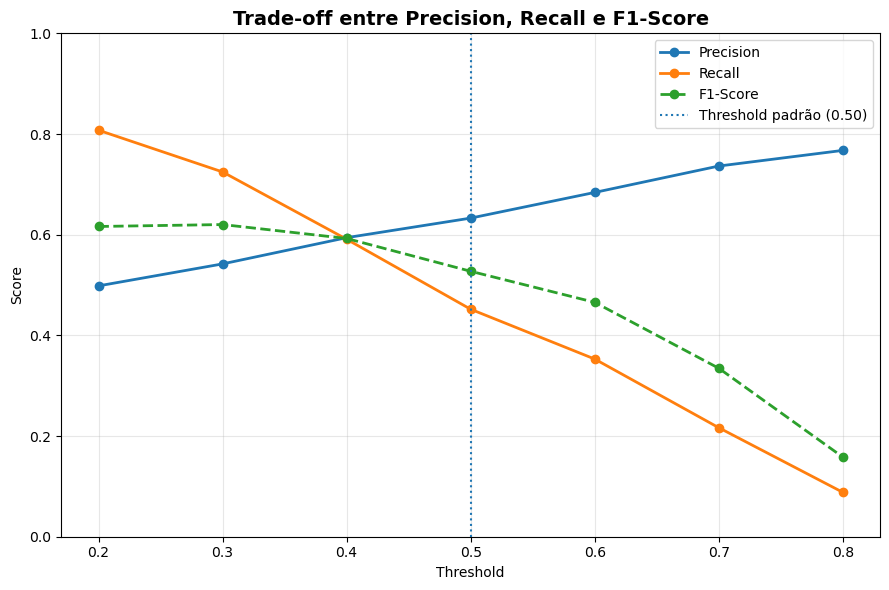

In [36]:
# ============================================================
# ETAPA 13.2 - TRADE-OFF PRECISION X RECALL
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    df_thresholds["Threshold"],
    df_thresholds["Precision"],
    marker="o",
    linewidth=2,
    label="Precision"
)

plt.plot(
    df_thresholds["Threshold"],
    df_thresholds["Recall"],
    marker="o",
    linewidth=2,
    label="Recall"
)

plt.plot(
    df_thresholds["Threshold"],
    df_thresholds["F1-Score"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="F1-Score"
)

plt.axvline(
    x=0.50,
    linestyle=":",
    linewidth=1.5,
    label="Threshold padrão (0.50)"
)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.title(
    "Trade-off entre Precision, Recall e F1-Score",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(
    df_thresholds["Threshold"]
)

plt.ylim(0, 1)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 13.3 - Trade-off entre Falsos Positivos e Falsos Negativos

A alteração do threshold também modifica diretamente a quantidade de falsos positivos e falsos negativos produzidos pelo modelo.

Em um cenário de churn:

- **Falsos Positivos (FP)** podem gerar custos desnecessários com campanhas ou ações de retenção direcionadas a clientes que permaneceriam na empresa;
- **Falsos Negativos (FN)** representam clientes que efetivamente realizam churn, mas não são identificados antecipadamente pelo modelo.

A análise conjunta desses erros permite avaliar qual threshold apresenta uma relação mais adequada entre o custo de abordar clientes desnecessariamente e o custo potencial de perder clientes não identificados.


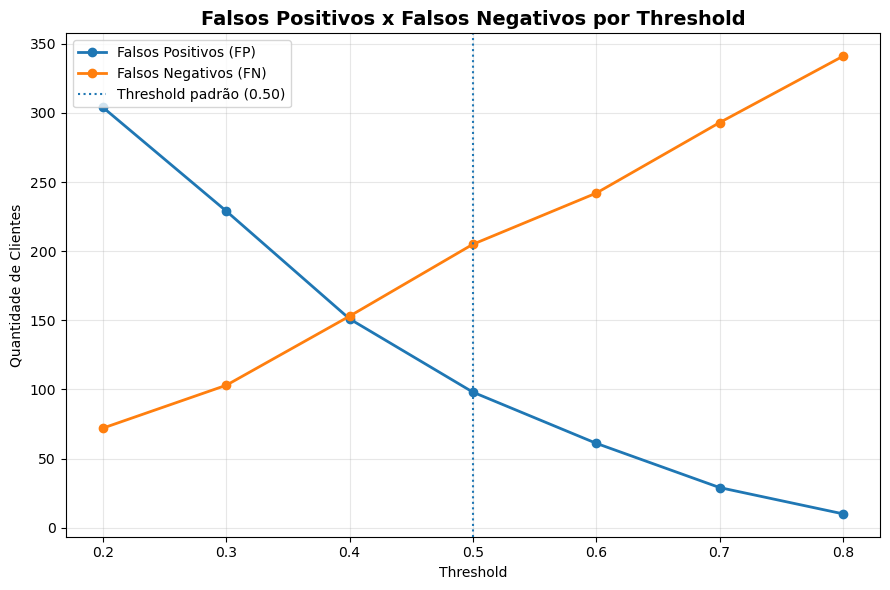

In [37]:
# ============================================================
# ETAPA 13.3 - FALSOS POSITIVOS X FALSOS NEGATIVOS
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    df_thresholds["Threshold"],
    df_thresholds["FP"],
    marker="o",
    linewidth=2,
    label="Falsos Positivos (FP)"
)

plt.plot(
    df_thresholds["Threshold"],
    df_thresholds["FN"],
    marker="o",
    linewidth=2,
    label="Falsos Negativos (FN)"
)

plt.axvline(
    x=0.50,
    linestyle=":",
    linewidth=1.5,
    label="Threshold padrão (0.50)"
)

plt.xlabel("Threshold")
plt.ylabel("Quantidade de Clientes")

plt.title(
    "Falsos Positivos x Falsos Negativos por Threshold",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(
    df_thresholds["Threshold"]
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 13.4 - Análise de Custo dos Erros por Threshold

Além das métricas técnicas, a escolha do threshold deve considerar o impacto dos diferentes tipos de erro para o negócio.

Como o dataset utilizado não fornece valores financeiros reais associados às ações de retenção ou à perda de clientes, será realizada uma **análise de custo relativo**, evitando assumir valores monetários não disponíveis nos dados.

Para esta simulação, serão considerados os seguintes pesos:

- **Falso Positivo (FP): 1 unidade de custo** — representa uma ação de retenção direcionada desnecessariamente a um cliente que permaneceria;
- **Falso Negativo (FN): 5 unidades de custo** — representa um cliente que efetivamente realiza churn, mas não é identificado antecipadamente.

O custo relativo total será calculado pela expressão:

**Custo Relativo = (FP × 1) + (FN × 5)**

A proporção 1:5 representa um cenário em que deixar de identificar um cliente que realizará churn possui impacto maior do que realizar uma ação de retenção desnecessária.

Essa análise constitui uma simulação de apoio à decisão e não representa custos financeiros reais da operadora.

In [38]:
# ============================================================
# ETAPA 13.4.1 - CUSTO RELATIVO DOS ERROS POR THRESHOLD
# ============================================================

custo_fp = 1
custo_fn = 5

df_custos = df_thresholds.copy()

df_custos["Custo FP"] = (
    df_custos["FP"] * custo_fp
)

df_custos["Custo FN"] = (
    df_custos["FN"] * custo_fn
)

df_custos["Custo Relativo Total"] = (
    df_custos["Custo FP"]
    + df_custos["Custo FN"]
)

# ------------------------------------------------------------
# Seleção das colunas para análise
# ------------------------------------------------------------

df_custos_resumo = df_custos[
    [
        "Threshold",
        "FP",
        "FN",
        "Custo FP",
        "Custo FN",
        "Custo Relativo Total"
    ]
].copy()

# ------------------------------------------------------------
# Formatação
# ------------------------------------------------------------

df_custos_resumo.style.format({
    "Threshold": "{:.2f}"
})

,Threshold,FP,FN,Custo FP,Custo FN,Custo Relativo Total
0,0.20,304,72,304,360,664
1,0.30,229,103,229,515,744
2,0.40,151,153,151,765,916
3,0.50,98,205,98,1025,1123
4,0.60,61,242,61,1210,1271
5,0.70,29,293,29,1465,1494
6,0.80,10,341,10,1705,1715


### 13.4.2 - Comparação dos Thresholds de Referência

A escolha do threshold pode variar de acordo com o objetivo adotado.

Para demonstrar essa diferença, serão comparados três critérios:

- **Threshold padrão:** ponto de corte de 0,50 utilizado originalmente pelo classificador;
- **Melhor F1-Score:** threshold que apresentou o maior equilíbrio entre Precision e Recall entre os valores avaliados;
- **Menor custo relativo:** threshold que apresentou o menor custo considerando a simulação em que um falso negativo possui peso cinco vezes maior que um falso positivo.

Essa comparação permite distinguir uma decisão baseada exclusivamente em desempenho estatístico de uma decisão orientada ao impacto dos erros para o negócio.

In [39]:
# ============================================================
# ETAPA 13.4.2 - THRESHOLDS DE REFERÊNCIA
# ============================================================

# Threshold com maior F1-Score
idx_melhor_f1 = df_thresholds["F1-Score"].idxmax()

threshold_melhor_f1 = df_thresholds.loc[
    idx_melhor_f1,
    "Threshold"
]

melhor_f1 = df_thresholds.loc[
    idx_melhor_f1,
    "F1-Score"
]


# Threshold com menor custo relativo
idx_menor_custo = df_custos[
    "Custo Relativo Total"
].idxmin()

threshold_menor_custo = df_custos.loc[
    idx_menor_custo,
    "Threshold"
]

menor_custo = df_custos.loc[
    idx_menor_custo,
    "Custo Relativo Total"
]


# Threshold padrão
threshold_padrao = 0.50

# ------------------------------------------------------------
# Resultados
# ------------------------------------------------------------

print("Thresholds de Referência - MLPClassifier\n")

print(
    f"Threshold padrão:       "
    f"{threshold_padrao:.2f}"
)

print(
    f"Melhor F1-Score:        "
    f"{threshold_melhor_f1:.2f} "
    f"(F1 = {melhor_f1:.4f})"
)

print(
    f"Menor custo relativo:   "
    f"{threshold_menor_custo:.2f} "
    f"(Custo = {menor_custo:.0f})"
)

Thresholds de Referência - MLPClassifier

Threshold padrão:       0.50
Melhor F1-Score:        0.30 (F1 = 0.6201)
Menor custo relativo:   0.20 (Custo = 664)


#### 13.5 - Conclusão da Análise de Threshold e Trade-off de Negócio

A análise dos diferentes thresholds demonstrou que o ponto de corte utilizado pelo MLPClassifier possui impacto significativo sobre a identificação dos clientes com risco de churn.

Com o **threshold padrão de 0,50**, o modelo apresentou Precision de **63,30%**, Recall de **45,19%** e F1-Score de **52,73%**. Nesse cenário, foram registrados **98 falsos positivos e 205 falsos negativos**, indicando que mais da metade dos clientes que efetivamente realizaram churn não foram identificados antecipadamente.

Entre os thresholds avaliados, o valor de **0,30 apresentou o maior F1-Score (0,6201)**, com Precision de **54,20%** e Recall de **72,46%**. Nesse ponto de corte, os falsos negativos foram reduzidos de 205 para 103, embora os falsos positivos tenham aumentado de 98 para 229.

A análise de custo relativo apresentou outro resultado. Considerando a hipótese de que um falso negativo possui custo cinco vezes maior que um falso positivo, o **threshold de 0,20 apresentou o menor custo relativo, com 664 unidades**. Nesse cenário, o Recall atingiu **80,75%**, com 72 falsos negativos e 304 falsos positivos.

A comparação evidencia que não existe um único threshold ideal independentemente do contexto. O threshold de **0,30** representa o melhor equilíbrio estatístico entre Precision e Recall dentre os valores avaliados, enquanto o threshold de **0,20** é mais adequado ao cenário simulado em que a não identificação de um cliente que realizará churn possui impacto substancialmente maior para o negócio.

Em comparação com o threshold padrão de 0,50, a utilização do threshold de 0,20 reduziria os falsos negativos de **205 para 72**, uma redução aproximada de **64,9%**, ao custo de elevar os falsos positivos de 98 para 304.

Portanto, para aplicações reais, a definição do threshold deve considerar os custos efetivos de uma ação de retenção e da perda de um cliente. Como esses valores não estão disponíveis no dataset, a análise de custo apresentada deve ser interpretada como uma **simulação de apoio à decisão**, e não como uma estimativa financeira real da operadora.

---

### ETAPA 14 - Validação Cruzada Estratificada

Após avaliar o MLPClassifier sobre o conjunto de teste, será realizada uma validação cruzada estratificada para analisar a estabilidade e a capacidade de generalização do modelo.

Será utilizado o **Stratified K-Fold**, que preserva aproximadamente a proporção das classes em cada divisão dos dados. Essa característica é particularmente importante no problema de churn devido ao desbalanceamento existente entre as classes.

A validação será realizada com **5 folds**, permitindo treinar e avaliar o modelo em diferentes subconjuntos dos dados.

Para evitar vazamento de dados, cada fold será tratado de forma independente, garantindo que o modelo seja treinado apenas com os dados pertencentes ao conjunto de treinamento daquele fold.

Serão avaliadas as métricas:

- Accuracy;
- Precision;
- Recall;
- F1-Score;
- ROC-AUC;
- Average Precision.

Ao final, serão analisadas a média e a variabilidade das métricas entre os folds.

In [40]:
# ============================================================
# ETAPA 14.1 - CONFIGURAÇÃO DA VALIDAÇÃO CRUZADA
# ============================================================

N_SPLITS = 5
RANDOM_STATE_CV = 42

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE_CV
)

print("Validação Cruzada Estratificada configurada.\n")

print(f"Número de folds: {skf.get_n_splits()}")
print("Shuffle: True")
print(f"Random State: {RANDOM_STATE_CV}")

Validação Cruzada Estratificada configurada.

Número de folds: 5
Shuffle: True
Random State: 42


In [41]:
# ============================================================
# VERIFICAÇÃO PARA A ETAPA 14.2
# ============================================================

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTipo de X:", type(X))
print("Tipo de y:", type(y))

print("\nDistribuição do target:")
print(y.value_counts())

print("\nProporção do target:")
print(y.value_counts(normalize=True).round(4))

X shape: (7043, 19)
y shape: (7043,)

Tipo de X: <class 'pandas.core.frame.DataFrame'>
Tipo de y: <class 'pandas.core.series.Series'>

Distribuição do target:
Churn
0    5174
1    1869
Name: count, dtype: int64

Proporção do target:
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64


### 14.3 - Execução da Validação Cruzada Estratificada

A validação cruzada será executada sobre o conjunto completo de dados utilizando o pipeline do MLPClassifier.

Como o pré-processamento está incorporado ao pipeline, as etapas de imputação, padronização e One-Hot Encoding serão ajustadas novamente dentro de cada fold utilizando exclusivamente os respectivos dados de treinamento.

Essa abordagem evita vazamento de informações entre treinamento e validação.

Em cada um dos cinco folds serão calculadas as métricas Accuracy, Precision, Recall, F1-Score, ROC-AUC e Average Precision.

In [42]:
# ============================================================
# ETAPA 14.3 - VALIDAÇÃO CRUZADA ESTRATIFICADA
# ============================================================

scoring_mlp = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}


# ------------------------------------------------------------
# Execução da validação cruzada
# ------------------------------------------------------------

start_time_cv = perf_counter()

cv_results_mlp = cross_validate(
    estimator=mlp_pipeline,
    X=X,
    y=y,
    cv=skf,
    scoring=scoring_mlp,
    return_train_score=False,
    n_jobs=-1
)

cv_time = (
    perf_counter() - start_time_cv
)

# ------------------------------------------------------------
# Informações gerais
# ------------------------------------------------------------

print(
    "Validação Cruzada Estratificada concluída.\n"
)

print(
    f"Número de folds: "
    f"{N_SPLITS}"
)

print(
    f"Tempo total: "
    f"{cv_time:.2f} segundos"
)

print(
    "\nMétricas calculadas:"
)

for metrica in scoring_mlp:
    print(
        f"- {metrica}"
    )

Validação Cruzada Estratificada concluída.

Número de folds: 5
Tempo total: 11.96 segundos

Métricas calculadas:
- accuracy
- precision
- recall
- f1
- roc_auc
- average_precision


### 14.4 - Resultados da Validação Cruzada por Fold

Após a execução da validação cruzada estratificada, as métricas obtidas em cada um dos cinco folds são apresentadas individualmente.

Essa análise permite verificar se o desempenho do MLPClassifier permanece consistente quando diferentes subconjuntos dos dados são utilizados para treinamento e validação.

Grandes variações entre os folds podem indicar instabilidade do modelo, enquanto resultados próximos sugerem maior capacidade de generalização.

In [43]:
# ============================================================
# ETAPA 14.4 - RESULTADOS POR FOLD
# ============================================================

df_cv_folds = pd.DataFrame({
    "Fold": range(1, N_SPLITS + 1),

    "Accuracy": cv_results_mlp[
        "test_accuracy"
    ],

    "Precision": cv_results_mlp[
        "test_precision"
    ],

    "Recall": cv_results_mlp[
        "test_recall"
    ],

    "F1-Score": cv_results_mlp[
        "test_f1"
    ],

    "ROC-AUC": cv_results_mlp[
        "test_roc_auc"
    ],

    "Average Precision": cv_results_mlp[
        "test_average_precision"
    ]
})

# ------------------------------------------------------------
# Tabela formatada
# ------------------------------------------------------------

df_cv_folds.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "Average Precision": "{:.4f}"
})

,Fold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Average Precision
0,1,0.8055,0.6799,0.5053,0.5798,0.8495,0.6427
1,2,0.7892,0.5970,0.6337,0.6148,0.8395,0.6600
2,3,0.8062,0.6391,0.6203,0.6296,0.8594,0.6837
3,4,0.7841,0.6049,0.5335,0.5670,0.8259,0.6240
4,5,0.7919,0.6262,0.5374,0.5784,0.8311,0.6314


### 14.5 - Média e Desvio-Padrão das Métricas

Após analisar individualmente os cinco folds, serão calculadas a média e o desvio-padrão das métricas obtidas na validação cruzada.

A média representa o desempenho geral do modelo ao longo das diferentes divisões dos dados, enquanto o desvio-padrão permite avaliar a variabilidade dos resultados.

Valores de desvio-padrão relativamente baixos indicam que o desempenho do modelo permanece consistente entre diferentes subconjuntos de treinamento e validação, fornecendo evidências de maior estabilidade e capacidade de generalização.

In [44]:
# ============================================================
# ETAPA 14.5 - MÉDIA E DESVIO-PADRÃO DAS MÉTRICAS
# ============================================================

metricas_cv = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "Average Precision"
]

resumo_cv = pd.DataFrame({
    "Métrica": metricas_cv,
    "Média": [
        df_cv_folds["Accuracy"].mean(),
        df_cv_folds["Precision"].mean(),
        df_cv_folds["Recall"].mean(),
        df_cv_folds["F1-Score"].mean(),
        df_cv_folds["ROC-AUC"].mean(),
        df_cv_folds["Average Precision"].mean()
    ],
    "Desvio-Padrão": [
        df_cv_folds["Accuracy"].std(),
        df_cv_folds["Precision"].std(),
        df_cv_folds["Recall"].std(),
        df_cv_folds["F1-Score"].std(),
        df_cv_folds["ROC-AUC"].std(),
        df_cv_folds["Average Precision"].std()
    ]
})

# ------------------------------------------------------------
# Formatação da tabela
# ------------------------------------------------------------

resumo_cv.style.format({
    "Média": "{:.4f}",
    "Desvio-Padrão": "{:.4f}"
})

,Métrica,Média,Desvio-Padrão
0,Accuracy,0.7954,0.0100
1,Precision,0.6294,0.0328
2,Recall,0.5661,0.0572
3,F1-Score,0.5939,0.0268
4,ROC-AUC,0.8411,0.0136
5,Average Precision,0.6484,0.0240


#### 14.6 - Interpretação da Validação Cruzada Estratificada

A validação cruzada estratificada com cinco folds permitiu avaliar o comportamento do MLPClassifier em diferentes divisões dos dados, preservando a proporção entre clientes com e sem churn.

O modelo apresentou **Accuracy média de 79,54% (± 1,00 p.p.)**, demonstrando baixa variação dessa métrica entre os folds.

A **Precision média foi de 62,94% (± 3,28 p.p.)**, enquanto o **Recall médio atingiu 56,61% (± 5,72 p.p.)**. O Recall apresentou a maior variabilidade entre as métricas avaliadas, indicando maior sensibilidade da identificação da classe positiva às diferentes divisões dos dados.

O **F1-Score médio foi de 59,39% (± 2,68 p.p.)**, representando o equilíbrio entre Precision e Recall ao longo dos cinco folds.

Em relação à capacidade discriminativa, o modelo apresentou **ROC-AUC médio de 0,8411 (± 0,0136)**. A baixa dispersão dessa métrica entre os folds indica comportamento consistente na capacidade de distinguir clientes com e sem churn.

A **Average Precision média foi de 0,6484 (± 0,0240)**, também apresentando variação relativamente limitada entre os folds e desempenho superior à prevalência da classe positiva no dataset, de aproximadamente 26,54%.

Os resultados da validação cruzada são compatíveis com a avaliação realizada anteriormente sobre o conjunto de teste. O ROC-AUC obtido no teste foi de **0,8341**, valor próximo à média de **0,8411** observada nos cinco folds.

Da mesma forma, a Accuracy do conjunto de teste foi de **78,50%**, próxima à média de **79,54%** da validação cruzada.

Entretanto, o Recall do conjunto de teste com threshold padrão foi de **45,19%**, abaixo da média de **56,61%** observada nos folds, reforçando que a capacidade de identificação dos clientes com churn apresenta maior variação e depende da amostra avaliada.

De forma geral, a validação cruzada fornece evidências de que o MLPClassifier apresenta desempenho relativamente consistente entre diferentes subconjuntos dos dados, especialmente em Accuracy e ROC-AUC. Entretanto, a maior variabilidade observada no Recall deve ser considerada na definição do threshold e na utilização do modelo em estratégias de retenção de clientes.

---

### ETAPA 15 - Análise de Convergência do MLPClassifier

Além das métricas de classificação, é importante analisar o comportamento do MLPClassifier durante o processo de treinamento.

Como o modelo foi configurado com **Early Stopping**, o treinamento pode ser interrompido antes do número máximo de iterações quando não são observadas melhorias suficientes no desempenho de validação.

Nesta etapa serão analisados:

- número de iterações realizadas;
- evolução da função de perda (loss);
- comportamento do score de validação utilizado pelo Early Stopping;
- melhor score de validação alcançado;
- evidências de convergência do treinamento.

Essa análise permite compreender se a rede neural apresentou aprendizado progressivo e se o mecanismo de Early Stopping atuou adequadamente.

In [45]:
# ============================================================
# ETAPA 15.1 - INFORMAÇÕES DE CONVERGÊNCIA DO MLP
# ============================================================

mlp_model = mlp_pipeline.named_steps["classifier"]

print("Convergência do MLPClassifier\n")

print(
    f"Iterações realizadas: "
    f"{mlp_model.n_iter_}"
)

print(
    f"Máximo configurado:   "
    f"{mlp_model.max_iter}"
)

print(
    f"Loss final:           "
    f"{mlp_model.loss_:.6f}"
)

print(
    f"Early Stopping:       "
    f"{mlp_model.early_stopping}"
)

print(
    f"Tamanho da curva de loss: "
    f"{len(mlp_model.loss_curve_)}"
)

# ------------------------------------------------------------
# Informações de validação do Early Stopping
# ------------------------------------------------------------

if hasattr(mlp_model, "validation_scores_"):

    print(
        f"Scores de validação registrados: "
        f"{len(mlp_model.validation_scores_)}"
    )

    print(
        f"Melhor score de validação: "
        f"{mlp_model.best_validation_score_:.4f}"
    )

Convergência do MLPClassifier

Iterações realizadas: 60
Máximo configurado:   300
Loss final:           0.356358
Early Stopping:       True
Tamanho da curva de loss: 60
Scores de validação registrados: 60
Melhor score de validação: 0.8316


#### 15.2 - Evolução da Função de Perda

A evolução da função de perda (loss) ao longo das iterações permite acompanhar o processo de aprendizado do MLPClassifier.

Uma redução progressiva da loss indica que o modelo está ajustando seus parâmetros para diminuir o erro durante o treinamento.

A análise gráfica também auxilia na identificação de estabilização, oscilações ou possíveis problemas durante o processo de otimização.

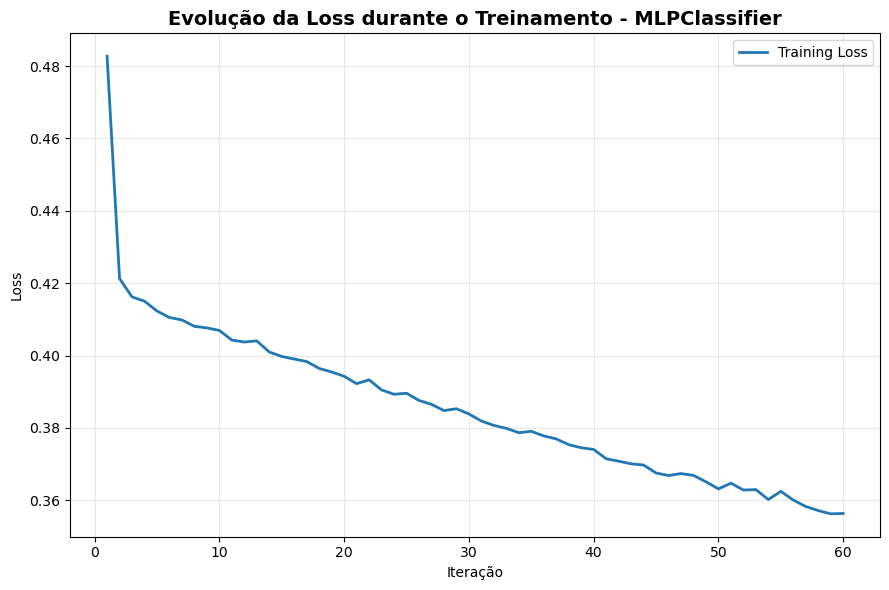

In [46]:
# ============================================================
# ETAPA 15.2 - CURVA DE LOSS DO MLPCLASSIFIER
# ============================================================

iteracoes_loss = range(
    1,
    len(mlp_model.loss_curve_) + 1
)

plt.figure(figsize=(9, 6))

plt.plot(
    iteracoes_loss,
    mlp_model.loss_curve_,
    linewidth=2,
    label="Training Loss"
)

plt.xlabel("Iteração")
plt.ylabel("Loss")

plt.title(
    "Evolução da Loss durante o Treinamento - MLPClassifier",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 15.3 - Evolução do Score de Validação

Como o MLPClassifier foi configurado com Early Stopping, uma parcela dos dados de treinamento é utilizada internamente para acompanhar o desempenho de validação durante o processo de aprendizado.

Enquanto a curva de loss representa a evolução do erro sobre os dados utilizados no treinamento, o score de validação permite verificar se as melhorias observadas durante o ajuste dos parâmetros também se refletem em dados não utilizados diretamente na otimização.

A análise conjunta das duas curvas auxilia na compreensão do momento em que o treinamento deixou de produzir melhorias relevantes de generalização.

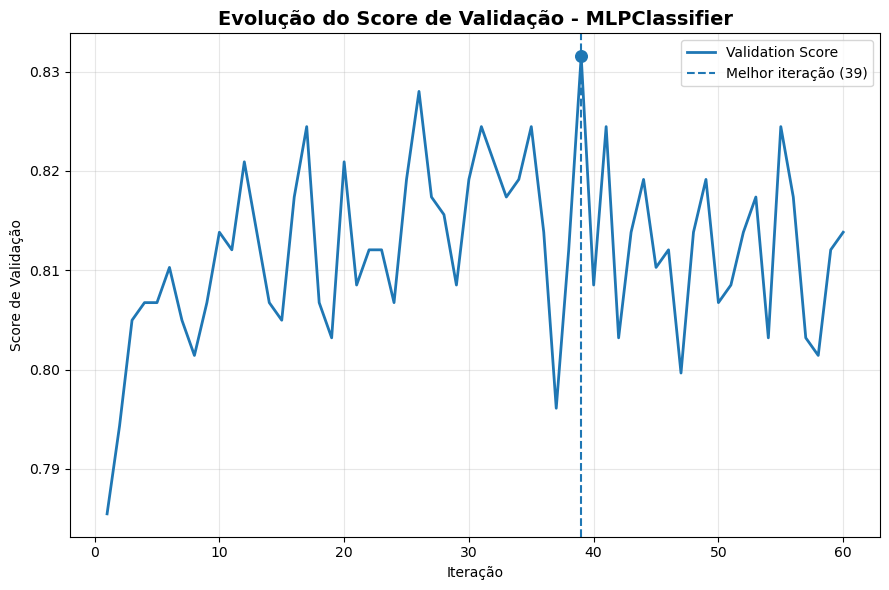

Early Stopping - MLPClassifier

Melhor iteração observada: 39
Melhor score de validação: 0.8316
Treinamento encerrado na iteração: 60


In [47]:
# ============================================================
# ETAPA 15.3 - SCORE DE VALIDAÇÃO DO EARLY STOPPING
# ============================================================

validation_scores = mlp_model.validation_scores_

iteracoes_validation = range(
    1,
    len(validation_scores) + 1
)

melhor_iteracao = (
    np.argmax(validation_scores) + 1
)

melhor_validation_score = (
    np.max(validation_scores)
)

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    iteracoes_validation,
    validation_scores,
    linewidth=2,
    label="Validation Score"
)

plt.axvline(
    x=melhor_iteracao,
    linestyle="--",
    linewidth=1.5,
    label=f"Melhor iteração ({melhor_iteracao})"
)

plt.scatter(
    melhor_iteracao,
    melhor_validation_score,
    s=70,
    zorder=3
)

plt.xlabel("Iteração")
plt.ylabel("Score de Validação")

plt.title(
    "Evolução do Score de Validação - MLPClassifier",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Resumo
# ------------------------------------------------------------

print("Early Stopping - MLPClassifier\n")

print(
    f"Melhor iteração observada: "
    f"{melhor_iteracao}"
)

print(
    f"Melhor score de validação: "
    f"{melhor_validation_score:.4f}"
)

print(
    f"Treinamento encerrado na iteração: "
    f"{mlp_model.n_iter_}"
)

#### 15.4 - Interpretação da Convergência e do Early Stopping

A análise das curvas de treinamento e validação permite compreender o comportamento do MLPClassifier durante o processo de aprendizado.

A função de perda apresentou redução consistente ao longo das **60 iterações**, passando de valores próximos de 0,48 nas primeiras iterações para uma loss final de **0,356358**. A trajetória predominantemente decrescente indica que o processo de otimização continuou ajustando os parâmetros da rede e reduzindo o erro sobre os dados de treinamento.

Entretanto, o comportamento do score de validação foi diferente. O melhor resultado foi alcançado na **iteração 39**, com score de validação de **0,8316**. Após esse ponto, ocorreram oscilações no desempenho de validação, sem que o melhor resultado fosse superado.

O treinamento foi encerrado na **iteração 60**, apesar de ter sido configurado um máximo de 300 iterações. Esse comportamento é consistente com a atuação do mecanismo de **Early Stopping**, que interrompe o treinamento quando novas iterações deixam de produzir melhoria suficiente no desempenho de validação durante o período de tolerância configurado.

A análise conjunta mostra que a redução contínua da loss de treinamento após a melhor iteração de validação não resultou em melhoria equivalente sobre os dados de validação. Dessa forma, continuar o treinamento até as 300 iterações configuradas não apresentava evidência de ganho adicional de generalização naquele processo de treinamento.

O Early Stopping permitiu, portanto, interromper o treinamento antecipadamente e limitar ajustes adicionais que não estavam produzindo melhora no score de validação.

Em conjunto com os resultados da validação cruzada estratificada, essa análise fornece evidências de um processo de treinamento controlado e de desempenho relativamente consistente do MLPClassifier.

---

### ETAPA 16 - Resumo Final dos Resultados do MLPClassifier

Após o treinamento e a avaliação do MLPClassifier, os principais resultados obtidos são consolidados nesta etapa.

Foram analisados:

- desempenho no conjunto de teste;
- matriz de confusão;
- Curva ROC e ROC-AUC;
- Curva Precision-Recall e Average Precision;
- comportamento em diferentes thresholds;
- trade-off entre falsos positivos e falsos negativos;
- simulação de custo relativo;
- validação cruzada estratificada;
- convergência do treinamento e Early Stopping.

A consolidação dessas informações permite resumir o comportamento técnico do modelo e preparar seus resultados para posterior comparação com os modelos baseline.

In [48]:
# ============================================================
# ETAPA 16.1 - RESUMO FINAL DO MLPCLASSIFIER
# ============================================================

resumo_final_mlp = pd.DataFrame({

    "Indicador": [
        "Accuracy - Teste",
        "Precision - Teste",
        "Recall - Teste",
        "F1-Score - Teste",
        "ROC-AUC - Teste",
        "Average Precision - Teste",

        "Accuracy - CV Média",
        "Precision - CV Média",
        "Recall - CV Média",
        "F1-Score - CV Média",
        "ROC-AUC - CV Média",
        "Average Precision - CV Média",

        "Melhor F1 - Threshold",
        "Threshold do Melhor F1",

        "Menor Custo Relativo",
        "Threshold do Menor Custo",

        "Melhor Validation Score",
        "Melhor Iteração",
        "Iterações Realizadas"
    ],

    "Valor": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        average_precision,

        resumo_cv.loc[
            resumo_cv["Métrica"] == "Accuracy",
            "Média"
        ].iloc[0],

        resumo_cv.loc[
            resumo_cv["Métrica"] == "Precision",
            "Média"
        ].iloc[0],

        resumo_cv.loc[
            resumo_cv["Métrica"] == "Recall",
            "Média"
        ].iloc[0],

        resumo_cv.loc[
            resumo_cv["Métrica"] == "F1-Score",
            "Média"
        ].iloc[0],

        resumo_cv.loc[
            resumo_cv["Métrica"] == "ROC-AUC",
            "Média"
        ].iloc[0],

        resumo_cv.loc[
            resumo_cv["Métrica"] == "Average Precision",
            "Média"
        ].iloc[0],

        melhor_f1,
        threshold_melhor_f1,

        menor_custo,
        threshold_menor_custo,

        melhor_validation_score,
        melhor_iteracao,
        mlp_model.n_iter_
    ]
})

# ------------------------------------------------------------
# Exibição
# ------------------------------------------------------------

resumo_final_mlp.style.format({
    "Valor": "{:.4f}"
})

,Indicador,Valor
0,Accuracy - Teste,0.7850
1,Precision - Teste,0.6330
2,Recall - Teste,0.4519
3,F1-Score - Teste,0.5273
4,ROC-AUC - Teste,0.8341
5,Average Precision - Teste,0.6231
6,Accuracy - CV Média,0.7954
7,Precision - CV Média,0.6294
8,Recall - CV Média,0.5661
9,F1-Score - CV Média,0.5939


### 16.2 - Conclusão Técnica do MLPClassifier

O MLPClassifier apresentou desempenho consistente na tarefa de previsão de churn, demonstrando capacidade relevante de discriminar clientes com maior e menor risco de cancelamento.

No conjunto de teste, o modelo obteve **Accuracy de 78,50%**, **Precision de 63,30%**, **Recall de 45,19%**, **F1-Score de 52,73%**, **ROC-AUC de 0,8341** e **Average Precision de 0,6231**.

A análise da matriz de confusão mostrou que, utilizando o threshold padrão de 0,50, o modelo identificou corretamente 169 dos 374 clientes que efetivamente realizaram churn, enquanto 205 clientes não foram identificados. Esse comportamento reforçou a necessidade de avaliar diferentes pontos de corte.

A análise de thresholds demonstrou que o valor de **0,30 apresentou o maior F1-Score entre os thresholds avaliados, com 0,6201**, elevando o Recall para 72,46%. Já na simulação de custo relativo, considerando um falso negativo com peso cinco vezes superior a um falso positivo, o **threshold de 0,20 apresentou o menor custo relativo, com 664 unidades**, além de alcançar Recall de 80,75%.

Esses resultados demonstram que a escolha do threshold deve estar associada ao objetivo de negócio. O threshold padrão de 0,50 não necessariamente representa o ponto de corte mais adequado para uma estratégia de retenção, principalmente quando o custo de não identificar um cliente que realizará churn é superior ao custo de uma abordagem preventiva desnecessária.

A validação cruzada estratificada com cinco folds apresentou **ROC-AUC médio de 0,8411 (± 0,0136)**, **Accuracy média de 79,54% (± 1,00 p.p.)** e **F1-Score médio de 59,39% (± 2,68 p.p.)**. Os resultados indicam desempenho relativamente consistente entre diferentes divisões dos dados, embora o Recall tenha apresentado maior variabilidade, com média de 56,61% e desvio-padrão de 5,72 pontos percentuais.

A análise do treinamento mostrou redução progressiva da função de perda, atingindo **loss final de 0,356358**. O melhor score de validação, **0,8316**, foi observado na iteração 39. Com o mecanismo de Early Stopping ativado, o treinamento foi encerrado após 60 iterações, embora o limite máximo estivesse configurado em 300.

De forma geral, o MLPClassifier apresentou boa capacidade discriminativa e comportamento relativamente estável. Entretanto, sua utilização em um cenário real de retenção exige a definição do threshold com base nos custos efetivos associados aos falsos positivos, falsos negativos e às ações de retenção.

Os resultados obtidos neste notebook serão utilizados posteriormente para comparação com os modelos baseline de Regressão Logística e Random Forest, permitindo avaliar qual abordagem apresenta o melhor equilíbrio entre desempenho técnico e impacto para o negócio.

### 16.3 - Status Final

**Modelo:** MLPClassifier  
**Validação:** Hold-out estratificado + Stratified 5-Fold Cross-Validation  
**Early Stopping:** Ativado  
**ROC-AUC no teste:** 0,8341  
**ROC-AUC médio na validação cruzada:** 0,8411  
**Melhor threshold por F1-Score entre os avaliados:** 0,30  
**Threshold de menor custo relativo na simulação 1:5:** 0,20  

---